<a href="https://colab.research.google.com/github/parthvargiya/liver-patient-model/blob/main/liver_patient.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

IMPORTING THE LIBRARIES

In [1]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

DATA IMP AND ANALYSIS

In [2]:
# LOAD THE CSV DATA FILE
df = pd.read_csv("/content/indian_liver_patient.csv") # FILE PATH OF THE CSV DATA

In [3]:
# REMOVE EXTRA SPACES IN COLUMN NAME
df.columns = df.columns.str.strip()

In [4]:
# FILL NULL VALUES WITH ZEROES
df['Albumin_and_Globulin_Ratio'] = df['Albumin_and_Globulin_Ratio'].fillna(0)

In [5]:
# DATAFRAME INFO
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  583 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [6]:
# PRINT FIRST 5 ROWS OF THE DATASET
df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


In [7]:
# NUMBER OF ROWS AND COLUMNS
df.shape

(583, 11)

In [8]:
# LAST CHECK FOR MISSING VALUES
df.isnull().sum()

,0
Age,0
Gender,0
Total_Bilirubin,0
Direct_Bilirubin,0
Alkaline_Phosphotase,0
Alamine_Aminotransferase,0
Aspartate_Aminotransferase,0
Total_Protiens,0
Albumin,0
Albumin_and_Globulin_Ratio,0


In [9]:
# STATISTICAL MEASURES ABOUT THE DATA
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.940566,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.327962,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.000000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.920000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [10]:
# DISTRUBUTION OF TARGET VARIABLE
df["Dataset"].value_counts() # 1 REPRESENTS LIVER PATIENTS & 2 REPRESENTS NON-LIVER PATIENTS

,count
Dataset,
1,416
2,167


In [11]:
# GROUPING OF THE DATA BASED ON THE TARGET VARIABLE
df.groupby('Dataset').mean(numeric_only=True)

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
Dataset,,,,,,,,,
1,46.153846,4.164423,1.923558,319.007212,99.605769,137.699519,6.459135,3.060577,0.909784
2,41.239521,1.142515,0.396407,219.754491,33.652695,40.688623,6.543114,3.344311,1.017246


DATA PRE-PROCESSING

SEPARATING TARGET VAR & FEATURES

In [12]:
# GENDER WISE MALE: 1 FEMALE: 0
df['Gender'] = df['Gender'].map({'Male': 0, 'Female': 1})

In [13]:
x = df.drop(columns=['Dataset'], axis=1)
y = df['Dataset']

In [14]:
print(x)

     Age  Gender  Total_Bilirubin  Direct_Bilirubin  Alkaline_Phosphotase  \
0     65       1              0.7               0.1                   187   
1     62       0             10.9               5.5                   699   
2     62       0              7.3               4.1                   490   
3     58       0              1.0               0.4                   182   
4     72       0              3.9               2.0                   195   
..   ...     ...              ...               ...                   ...   
578   60       0              0.5               0.1                   500   
579   40       0              0.6               0.1                    98   
580   52       0              0.8               0.2                   245   
581   31       0              1.3               0.5                   184   
582   38       0              1.0               0.3                   216   

     Alamine_Aminotransferase  Aspartate_Aminotransferase  Total_Protiens  

In [15]:
print(y)

0      1
1      1
2      1
3      1
4      1
      ..
578    2
579    1
580    1
581    1
582    2
Name: Dataset, Length: 583, dtype: int64


SPLIT TRAINING & TESTING DATA

In [16]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state=2)

In [17]:
print(x.shape, x_train.shape, x_test.shape)

(583, 10) (466, 10) (117, 10)


DATA STANDARDIZATION

In [18]:
scaler = StandardScaler()

In [19]:
scaler.fit(x_train)

StandardScaler()

In [20]:
x_train = scaler.transform(x_train)

x_test = scaler.transform(x_test)

In [21]:
print(x_train)

[[ 0.6104296   1.7470472  -0.40195703 ... -0.37639247  0.18005752
   0.77763735]
 [ 0.36562737 -0.57239438 -0.18388072 ...  0.74856032 -0.71940285
  -1.20074627]
 [ 0.18202569  1.7470472  -0.30849575 ...  0.65481426  0.95102354
   0.47327064]
 ...
 [ 1.22243518 -0.57239438 -0.41753391 ... -1.22010706 -1.74735755
  -1.29205629]
 [-0.30757877 -0.57239438  0.01861872 ...  0.56106819  0.30855185
  -0.13546278]
 [ 0.91643239 -0.57239438  3.02495648 ...  0.37357606  0.18005752
  -0.13546278]]


MODEL TRAINING

In [22]:
model = svm.SVC(kernel='linear')

In [23]:
# TRAINING SVM MODEL WITH TRAINING DATA
model.fit(x_train, y_train)


SVC(kernel='linear')

MODEL EVALUATION

ACCURACY SCORE

In [24]:
# ACCURACY OF TRAINING DATA
x_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(y_train, x_train_prediction)

In [25]:
print("ACCURACY SCORE OF TRAINING DATA :", training_data_accuracy)

ACCURACY SCORE OF TRAINING DATA : 0.7103004291845494


In [26]:
# ACCURACY OF TESTNG DATA
x_test_prediction = model.predict(x_test)
testing_data_accuracy = accuracy_score(y_test, x_test_prediction)

In [27]:
print("ACCURACY SCORE OF TESTING DATA :", testing_data_accuracy)

ACCURACY SCORE OF TESTING DATA : 0.7264957264957265


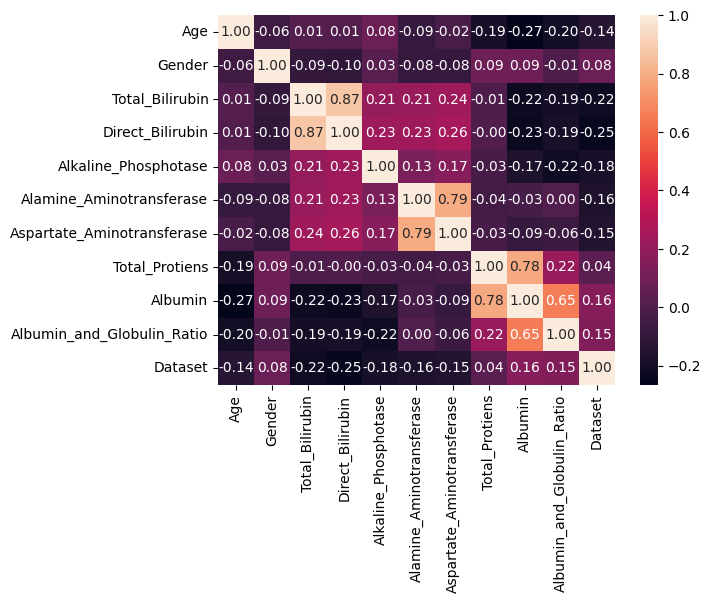

In [28]:
# TO CHECK SIMILARITIES AND DATA COLUMNS OVERLAP
sns.heatmap(df.corr(), annot=True, fmt='.2f')
plt.show()

BUILDING A PREDICTIVE SYSTEM

In [29]:
input_data = (65, 1, 0.7,	0.1,	187,	16,	18,	6.8,	3.3,	0.90)

# CHANGING THE INPUT DATA TO A NUMPY ARRAY
input_data_as_numpy_array = np.asarray(input_data)

# RESHAPE THE NUMPY ARRAY
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# STANDARDIZATION OF THE DATA
std_data = scaler.transform(input_data_reshaped)

prediction = model.predict(std_data)
print(prediction)

if prediction[0] == 1:
  print("THE PERSON IS A LIVER PATIENT")
else:
  print("THE PERSON IS NOT A LIVER PATIENT")

[1]
THE PERSON IS A LIVER PATIENT


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


SAVING THE TRAINED MODEL

In [30]:
import pickle

In [31]:
filename = 'trained_model.sav'
pickle.dump(model, open(filename, 'wb'))

scaler_file = 'scaler.sav'
pickle.dump(scaler, open(scaler_file, 'wb'))

In [32]:
# LOADING THE SAVED MODEL
loaded_model = pickle.load(open('trained_model.sav', 'rb'))

# SAVING SCALER OBJECT
pickle.dump(scaler, open('scaler.sav', 'wb'))

In [33]:
input_data = (65, 1, 0.7,	0.1,	187,	16,	18,	6.8,	3.3,	0.90)

# CHANGING THE INPUT DATA TO A NUMPY ARRAY
input_data_as_numpy_array = np.asarray(input_data)

# RESHAPE THE NUMPY ARRAY
input_data_reshaped = input_data_as_numpy_array.reshape(1, -1)

# STANDARDIZATION OF THE DATA
std_data = scaler.transform(input_data_reshaped)

prediction = loaded_model.predict(std_data)
print(prediction)

if prediction[0] == 1:
  print("THE PERSON IS A LIVER PATIENT")
else:
  print("THE PERSON IS NOT A LIVER PATIENT")

[1]
THE PERSON IS A LIVER PATIENT


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
